In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler


In [24]:
df = pd.read_csv("11_Baseketball_Team_Performance_Analysis.csv")
df.head()
df.shape

(10000, 37)

# Checking null values

In [25]:
df.isnull().sum()

id                                   0
year                                 0
rank                                 0
school                               0
games                                0
wins                                 0
losses                               0
win_percentage                       0
conference_wins                      0
conference_losses                    0
home_wins                          208
home_losses                        208
away_wins                          208
away_losses                        208
offensive_rating                   278
defensive_rating                   278
net_rating                         278
field_goals                          0
field_goal_attempts                  0
field_goal_percentage                0
3_pointers                          58
3_pointer_attempts                  58
3_pointer_percentage                58
effective_field_goal_percentage     58
free_throws                          0
free_throw_attempts      

# Filling null values with median

In [26]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Checking if nulls are gone
print("Nulls remaining:", df.isnull().sum().sum())

Nulls remaining: 0


# Checking for duplicates

In [27]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows: 0


# Outlier Detection

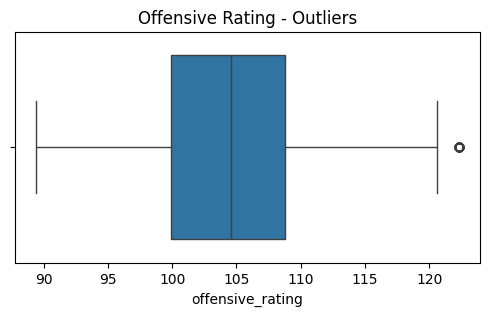

In [28]:
# Box plot for offensive rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['offensive_rating'])
plt.title('Offensive Rating - Outliers')
plt.show()

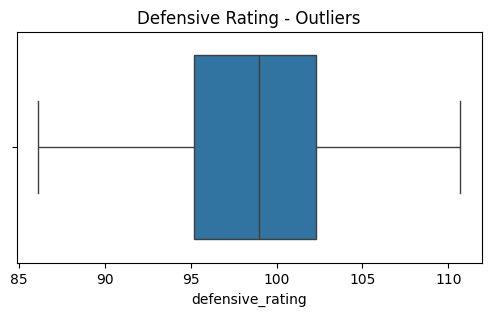

In [29]:
# Box plot for defensive rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['defensive_rating'])
plt.title('Defensive Rating - Outliers')
plt.show()

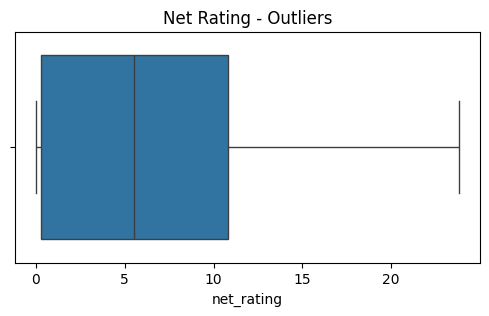

In [30]:
# Box plot for net rating
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['net_rating'])
plt.title('Net Rating - Outliers')
plt.show()

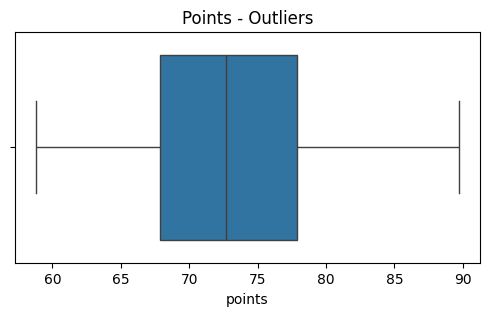

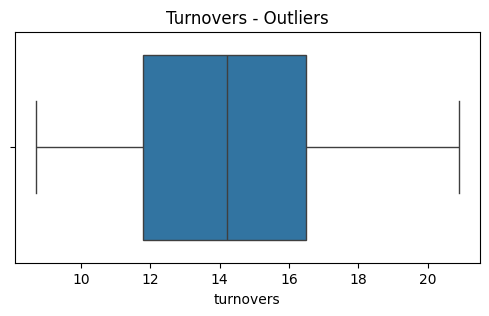

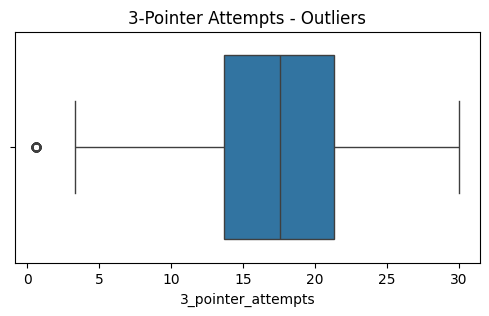

In [31]:
# Box plot for points and turnovers
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['points'])
plt.title('Points - Outliers')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['turnovers'])
plt.title('Turnovers - Outliers')
plt.show()

# Box plot for 3-pointer attempts
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['3_pointer_attempts'])
plt.title('3-Pointer Attempts - Outliers')
plt.show()

# Outlier Handling (IQR Method)

In [32]:
print("\nOutlier Handling:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers detected")
        # Cap outliers instead of removing (preserves data size)
        df[col] = df[col].clip(lower_bound, upper_bound)


Outlier Handling:
offensive_rating: 68 outliers detected
3_pointer_attempts: 62 outliers detected


# Skewness Analysis

In [33]:
print("Skewness Analysis:")
skewness_data = []
for col in numeric_cols:
    skew_val = stats.skew(df[col])
    skewness_data.append(f"{col}: {round(skew_val, 3)}")
    
for item in skewness_data:
    print(item)

print("\nInterpretation: |skewness| < 0.5 = fairly symmetrical, 0.5-1 = moderately skewed, > 1 = highly skewed")

Skewness Analysis:
id: 0.009
year: -0.004
rank: 0.039
games: -0.268
wins: 0.01
losses: -0.008
win_percentage: -0.242
conference_wins: -0.023
conference_losses: 0.034
home_wins: -0.104
home_losses: 0.017
away_wins: -0.001
away_losses: -0.011
offensive_rating: 0.062
defensive_rating: -0.083
net_rating: 0.757
field_goals: 0.31
field_goal_attempts: 0.141
field_goal_percentage: 0.165
3_pointers: -0.084
3_pointer_attempts: -0.236
3_pointer_percentage: -0.047
effective_field_goal_percentage: 0.21
free_throws: 0.26
free_throw_attempts: 0.185
free_throw_percentage: -0.015
offensive_rebounds: 0.224
total_rebounds: 0.095
assists: 0.054
steals: 0.145
blocks: 0.296
turnovers: 0.146
personal_fouls: 0.257
points: 0.043
opponent_points: 0.023
simple_rating: 0.011

Interpretation: |skewness| < 0.5 = fairly symmetrical, 0.5-1 = moderately skewed, > 1 = highly skewed


# Exploratory Visualizations

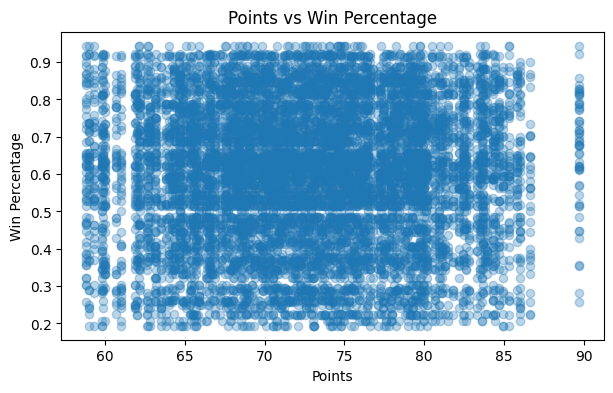

In [34]:
# Scatter plot - points vs win percentage
plt.figure(figsize=(7, 4))
plt.scatter(df['points'], df['win_percentage'], alpha=0.3)
plt.xlabel('Points')
plt.ylabel('Win Percentage')
plt.title('Points vs Win Percentage')
plt.show()

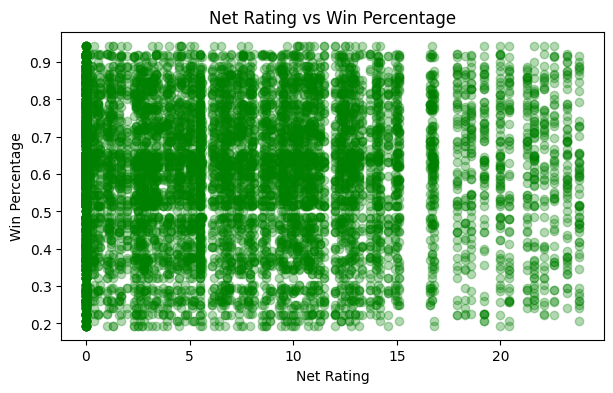

In [35]:
# Scatter plot - net rating vs win percentage
plt.figure(figsize=(7, 4))
plt.scatter(df['net_rating'], df['win_percentage'], alpha=0.3, color='green')
plt.xlabel('Net Rating')
plt.ylabel('Win Percentage')
plt.title('Net Rating vs Win Percentage')
plt.show()

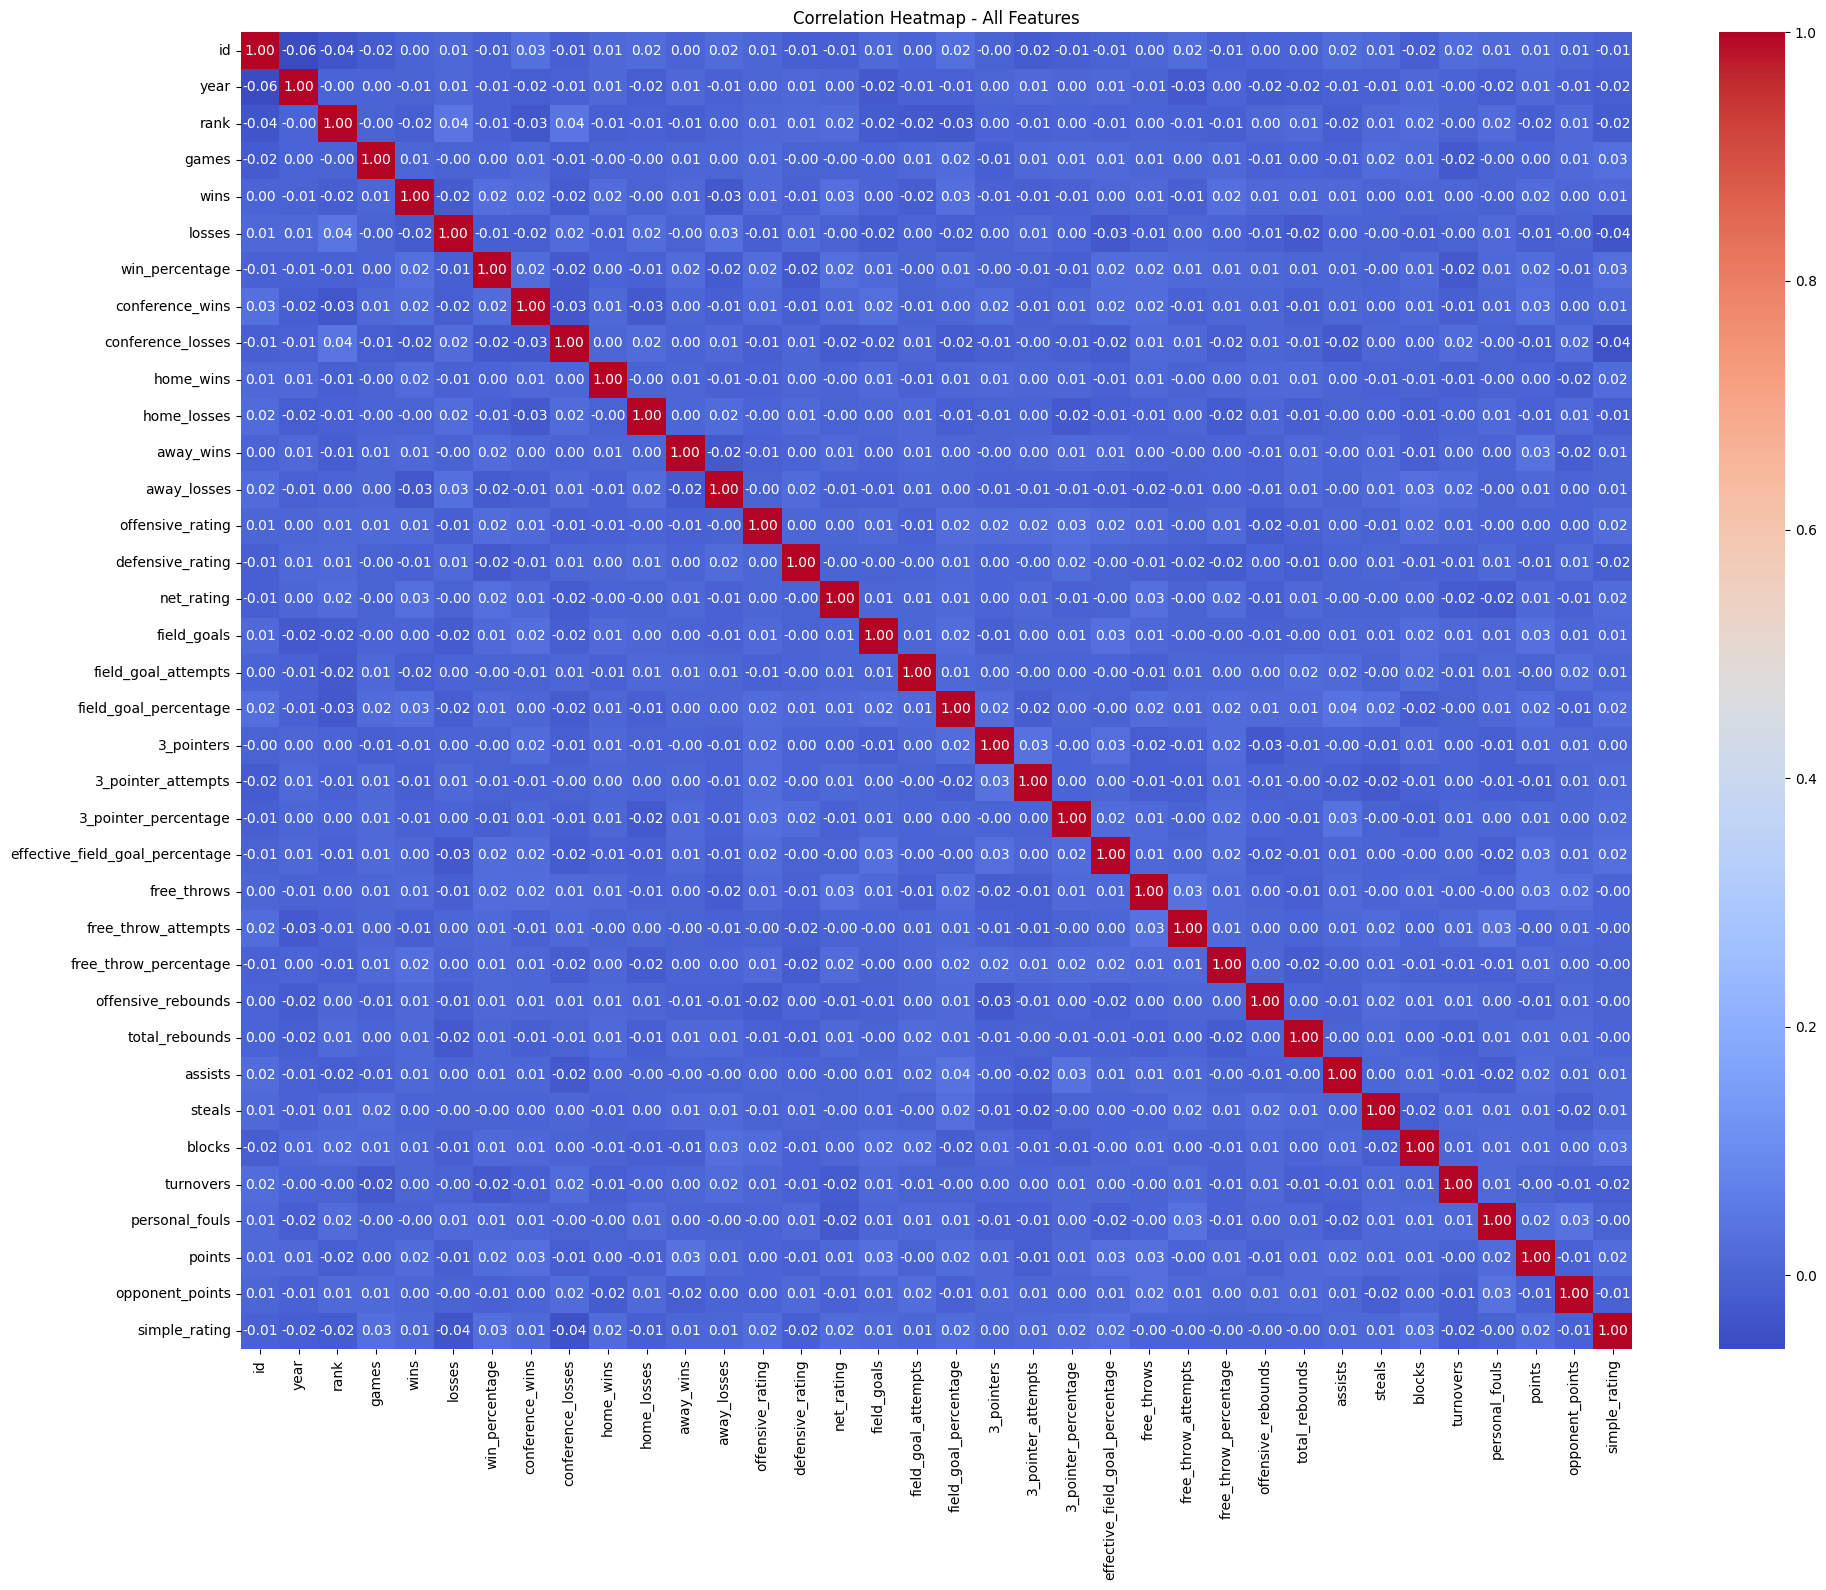

In [36]:
# Correlation heatmap
plt.figure(figsize=(20, 16))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - All Features')
plt.tight_layout()
plt.show()

# Feature Engineering

In [37]:
# 1. point difference = points scored - opponent points
df['point_diff'] = df['points'] - df['opponent_points']

# 2. assist to turnover ratio (safe division)
df['assist_turnover_ratio'] = np.where(df['turnovers'] == 0, 0, df['assists'] / df['turnovers'])

# 3. home win percentage (handle division by zero)
df['home_games'] = df['home_wins'] + df['home_losses']
df['home_win_pct'] = np.where(df['home_games'] == 0, 0.5, df['home_wins'] / df['home_games'])

# 4. away win percentage
df['away_games'] = df['away_wins'] + df['away_losses']
df['away_win_pct'] = np.where(df['away_games'] == 0, 0.5, df['away_wins'] / df['away_games'])

# 5. home court advantage
df['home_advantage'] = df['home_win_pct'] - df['away_win_pct']

# 6. conference win percentage
df['conf_games'] = df['conference_wins'] + df['conference_losses']
df['conf_win_pct'] = np.where(df['conf_games'] == 0, 0.5, df['conference_wins'] / df['conf_games'])

# 7. scoring efficiency
df['scoring_efficiency'] = np.where(df['field_goal_attempts'] == 0, 0, df['points'] / df['field_goal_attempts'])

# 8. defensive pressure
df['defensive_pressure'] = df['steals'] + df['blocks']

print("New features created!")

New features created!


# Feature Correlations with Win %

In [38]:
new_cols = ['point_diff', 'assist_turnover_ratio', 'home_advantage', 'conf_win_pct', 'scoring_efficiency', 'defensive_pressure']

for col in new_cols:
    corr_val = df[col].corr(df['win_percentage'])
    print(f"{col} -> correlation with win%: {round(corr_val, 3):.3f}")

point_diff -> correlation with win%: 0.021
assist_turnover_ratio -> correlation with win%: 0.019
home_advantage -> correlation with win%: -0.018
conf_win_pct -> correlation with win%: 0.025
scoring_efficiency -> correlation with win%: 0.019
defensive_pressure -> correlation with win%: 0.008


# Feature Engineering Visual

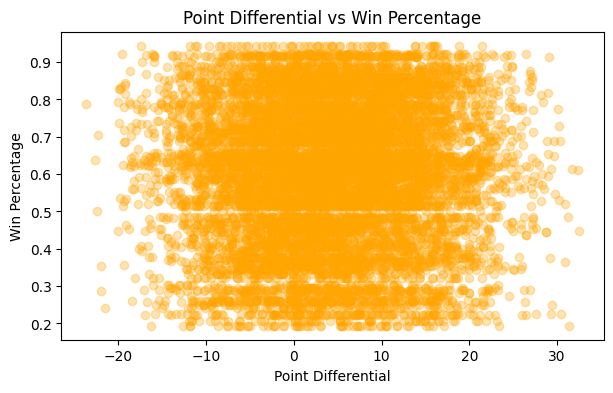

In [39]:
# Scatter plot of best new feature
plt.figure(figsize=(7, 4))
plt.scatter(df['point_diff'], df['win_percentage'], alpha=0.3, color='orange')
plt.xlabel('Point Differential')
plt.ylabel('Win Percentage')
plt.title('Point Differential vs Win Percentage')
plt.show()

# Normalization

In [40]:
scaler = StandardScaler()

# Get all numeric columns after feature engineering
all_numeric_cols = df.select_dtypes(include='number').columns.tolist()
features_to_scale = [col for col in all_numeric_cols if col != 'win_percentage']

# Fit and scale the features
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("Normalization completed!")
print("\nBefore scaling - Points (first 5):", df['points'].head().values)
print("After scaling - Points (first 5):", df_scaled['points'].head().values)
print("\nScaled data shape:", df_scaled.shape)

Normalization completed!

Before scaling - Points (first 5): [71.7 71.5 74.8 69.2 74. ]
After scaling - Points (first 5): [-0.16440056 -0.19451387  0.30235562 -0.54081684  0.18190241]

Scaled data shape: (10000, 48)


# Final Dataset

In [41]:
print("Final shape:", df.shape)
df.head()

Final shape: (10000, 48)


,id,year,rank,school,games,wins,losses,win_percentage,conference_wins,conference_losses,...,assist_turnover_ratio,home_games,home_win_pct,away_games,away_win_pct,home_advantage,conf_games,conf_win_pct,scoring_efficiency,defensive_pressure
0,1,2021,1,Villanova,38,30,8,0.789,16,4,...,1.202020,13.0,0.923077,13.0,0.615385,0.307692,20,0.800000,1.278075,8.2
1,2,2021,2,Providence,33,27,6,0.818,14,3,...,1.157895,17.0,0.941176,9.0,0.777778,0.163399,17,0.823529,1.269982,8.7
2,3,2021,3,UConn,33,23,10,0.697,13,6,...,1.186441,16.0,0.875000,10.0,0.500000,0.375000,19,0.684211,1.222222,12.3
3,4,2021,4,Creighton,35,23,12,0.657,12,7,...,0.943262,15.0,0.733333,11.0,0.545455,0.187879,19,0.631579,1.209790,9.8
4,5,2021,5,Marquette,32,19,13,0.594,11,8,...,1.290323,16.0,0.812500,11.0,0.363636,0.448864,19,0.578947,1.237458,13.0


# HYPOTHESIS TESTING
## Test 1: High Points lead to Higher Win Percentage
**H0**: No difference in win % between high/low points teams
**Test**: Independent t-test (split by median points)

Median points: 72.7
High points teams (n=4986): mean win% = 0.603
Low points teams (n=5014): mean win% = 0.598

T-test Results:
t-statistic = 1.356
p-value = 0.175240
Fail to reject H0


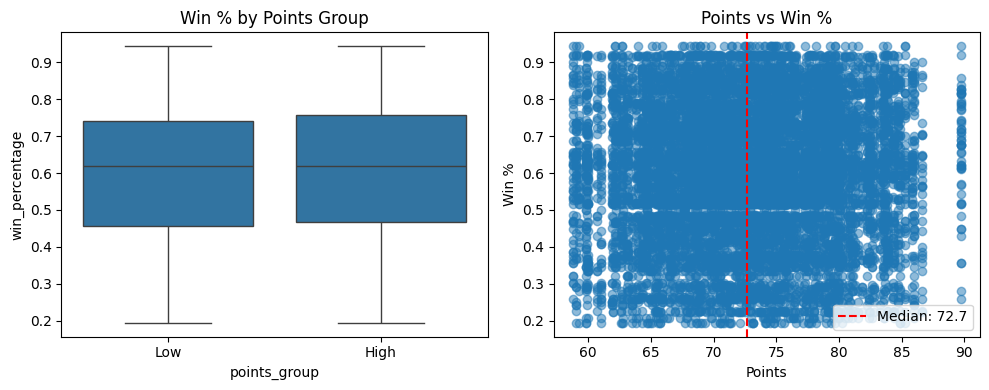

In [44]:
# Hypothesis Test 1: High Points vs Win Percentage

# Split by median points
median_points = df['points'].median()
print(f"Median points: {median_points:.1f}")

high_points = df[df['points'] > median_points]['win_percentage']
low_points = df[df['points'] <= median_points]['win_percentage']

print(f"High points teams (n={len(high_points)}): mean win% = {high_points.mean():.3f}")
print(f"Low points teams (n={len(low_points)}): mean win% = {low_points.mean():.3f}")

# t-test
t_stat, p_value = stats.ttest_ind(high_points, low_points)
print(f"\nT-test Results:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.6f}")

if p_value < 0.05:
    print("REJECT H0: High points teams have significantly higher win % (p < 0.05)")
else:
    print("Fail to reject H0")

# Create points_group column
df['points_group'] = df['points'] > median_points
df['points_group'] = df['points_group'].map({True: 'High', False: 'Low'})

# Visualization
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='points_group', y='win_percentage')
plt.title('Win % by Points Group')

plt.subplot(1, 2, 2)
plt.scatter(df['points'], df['win_percentage'], alpha=0.5)
plt.axvline(median_points, color='red', linestyle='--', label=f'Median: {median_points:.1f}')
plt.xlabel('Points')
plt.ylabel('Win %')
plt.title('Points vs Win %')
plt.legend()

plt.tight_layout()
plt.show()